In [1]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import plotly.express as px
import math

from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import (
    silhouette_score
)

import xgboost as xgb
from umap import UMAP
import shap

# =========================
# Custom utilities
# =========================
import utils.cross_validation as cval
import utils.umap_utils as uutil
import utils.exp_utils as exp

# =========================
# Optional helpers (math functions already included above)
# =========================
from math import radians, sin, cos, sqrt, asin



def select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=None):
    """
    Select exactly ONE point and remove ALL other points within buffer_km.
    
    Parameters:
    - df: DataFrame with coordinates
    - buffer_km: radius in km to remove points (default: 50)
    - lat_col: latitude column name
    - lon_col: longitude column name
    - random_seed: random seed for reproducibility
    - method: 'random' or 'first' or index
    
    Returns:
    - selected_df: DataFrame with 1 selected point
    - remaining_df: DataFrame with points > buffer_km away (kept)
    - removed_df: DataFrame with points <= buffer_km away (removed)
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
    

    selected_idx = np.random.choice(df.index, 1, replace=False)[0]
 
    # Get selected point coordinates
    selected_point = df.loc[selected_idx]
    lat_sel = selected_point[lat_col]
    lon_sel = selected_point[lon_col]
    
    # Classify all points
    selected_points = [selected_idx]
    removed_points = []
    remaining_points = []
    
    for idx in df.index:
        if idx == selected_idx:
            continue
        
        # Calculate distance to selected point
        dist = haversine(lat_sel, lon_sel, 
                        df.loc[idx, lat_col], 
                        df.loc[idx, lon_col])
        
        if dist <= buffer_km:
            removed_points.append(idx)  # Too close → remove
        else:
            remaining_points.append(idx)  # Far enough → keep
    
    # Create DataFrames
    selected_df = df.loc[selected_points].copy()
    removed_df = df.loc[removed_points].copy()
    remaining_df = df.loc[remaining_points].copy()
    
    print(f"✓ Removed {len(removed_df)} points within {buffer_km}km")
    
    return selected_df, remaining_df, removed_df


def train_test_split_v3(df, random_key, n_points_to_select=2, buffer_km=100):

    # selected, remaining, removed = select_points_stratified(sub_df, 
    #     n_per_biome=n_points_to_select,
    #     buffer_km=buffer_km,
    #     lat_col='lat',
    #     lon_col='lon',
    #     random_seed=random_key
    # )
    selected, remaining, removed = select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=random_key)
    

    test = selected.drop(columns=['lat', 'lon', 'biome'])
    test_biomes=selected[['biome']]
    train= remaining.drop(columns=['lat', 'lon', 'biome'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID'])

    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID' ])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test, test_biomes, scaler


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c



/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Essential Params and Dicts

color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}

biome_colors = {
'Temperate broadleaf forests': '#E67E22',      # Vibrant Orange
'Temperate conifer forests': '#2E86C1',        # Bright Blue
'Temperate grasslands': '#F1C40F',             # Bright Yellow
'Xeric shrublands': '#E74C3C',                 # Bright Red
'Boreal and Tundra forests': '#1ABC9C',        # Teal
'Mediterranean woodlands': '#8E44AD',          # Purple
'Tropical': '#2ECC71',                         # Emerald Green
'Flooded grasslands': '#3498DB',               # Royal Blue
'Mangroves': '#27AE60',                        # Dark Green
'NaN': '#BDC3C7'                               # Light Gray
}


biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]

In [4]:

with open("config/ex_config.yaml", "r") as f:
    config = yaml.safe_load(f)

biome_mapping = config["biome_mapping"]
random_key=config["random_key"]

biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]

## Local Explainability 


In [5]:
fd_df = pd.read_csv('data/final/final_dataset.csv')
PID_df= pd.read_csv('data/lookup/PID_location_all.csv')

fd_df=fd_df.merge(PID_df[['PID','lat','lon', 'biome']], on='PID', how='left')

fd_df.dropna(subset=['transformed npp', 'Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                    'Species Richness', 'Shannon Diversity', "Simpson's Index"], inplace=True)
fd_df = fd_df[fd_df["treecover2000"] > 60]

fd_df.drop_duplicates(subset=['PID'], inplace=True)

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]
#Preprocessing the data for Random forest regression

fd_df['biome'] = fd_df['biome'].map(biome_mapping) # Only run this once ! 

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}

In [6]:
def plot_shap_with_polynomial_stats_v3(shap_values, X, features, biome=None, pdp_curves=None, degree=2, name=None,
                                        biome_color=None):
    
    """
    Plot SHAP dependence with polynomial trend and statistics.
    Single feature list, one plot per feature, no overlapping axes.
    Line colour is taken from biome_color dict if provided and biome is specified.
    """
    default_colors = {
        'scatter': "#999CC2",
        'line':    "#3E47C6",
    }

    # Resolve line colour from biome_color dict if available
    if biome is not None and biome_color is not None and biome in biome_color:
        line_color = biome_color[biome]
        # Lighten for scatter by adding transparency — handled via alpha
        scatter_color = line_color
    else:
        line_color    = default_colors['line']
        scatter_color = default_colors['scatter']

    n_plots = len(features)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)
    n_samples = min(shap_values.shape[0], 2000)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = np.array(axes).flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.4)
    slopes=[]
    zeros=[]
    pdp_curves[biome] = {}

    for i, (ax, var) in enumerate(zip(axes_flat, features)):

        feature_values = X[var].values.astype(np.float64)
        feature_idx = list(X.columns).index(var)
        shap_feature = shap_values[:, feature_idx].astype(np.float64)

        # Skip if all zeros
        if np.all(feature_values == 0):
            ax.set_visible(False)
            slopes.append(np.nan)
            zeros.append(np.nan)
            continue

        # Sample
        indices = np.random.choice(len(feature_values), n_samples, replace=False)
        fv_sample = feature_values[indices]
        sv_sample = shap_feature[indices]

        # Polynomial fit on full data
        coeffs = np.polyfit(feature_values, shap_feature, degree)
        poly_func = np.poly1d(coeffs)
        poly_deriv = np.polyder(poly_func)
        midpoint = np.median(feature_values)
        slopes.append(poly_deriv(midpoint))

        # Zero crossing — find where polynomial crosses y=0
        x_smooth = np.linspace(feature_values.min(), feature_values.max(), 20000)
        y_smooth = poly_func(x_smooth)
        zeros.append((np.where(np.diff(np.sign(y_smooth)))[0]))  
        # R²
        y_pred = poly_func(feature_values)
        ss_res = np.sum((shap_feature - y_pred) ** 2)
        ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        # Scatter
        ax.scatter(fv_sample, sv_sample,
                   alpha=0.2, s=20, c=scatter_color,
                   linewidth=0.3, zorder=1)

        # Trend line
        x_smooth = np.linspace(feature_values.min(), feature_values.max(), 200)
        y_smooth = poly_func(x_smooth)
        ax.plot(x_smooth, y_smooth,
                c=line_color, linewidth=2,
                label=f'Degree {degree} poly | R²={r2:.3f}',
                zorder=10)
        pdp_curves[biome][var] = (x_smooth, y_smooth)
        # Reference line
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)

        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel('SHAP value', fontsize=10)
        ax.set_title(f'{var}', fontsize=11, pad=8)
        ax.legend(fontsize=8, loc='best')

        y_min = np.min(y_smooth)
        y_max = np.max(y_smooth)
        padding = 0.1 * (y_max - y_min)
        ax.set_ylim(y_min - padding, y_max + padding)

    # Hide unused axes
    for ax in axes_flat[n_plots:]:
        ax.set_visible(False)

    title = f'SHAP Dependence — {biome}' if biome else 'SHAP Dependence'
    fig.suptitle(title, fontsize=13, y=1.02)

    if name:
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()
    return slopes, zeros

def plot_shap_with_polynomial_stats_v2(shap_values, X, div_f, div_s,biome, degree=2, name=None):
    """Plot SHAP dependence with polynomial trend and statistics"""
    
    paired_vars = list(zip(div_f, div_s))

    colors_f = "#125F10"
    colors_f1= "#94BC92"
    colors_s = "#8040a0"
    colors_s1= "#cca9dd"

    # Get data
    n_plots = len(div_f)
    n_cols = 2  # or any number you prefer
    n_rows = math.ceil(n_plots / n_cols)

    if shap_values.shape[0] < 2000:
        n_samples = shap_values.shape[0]
    else:
        n_samples = 2000

    # 2 rows x 2 cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = axes.flatten()  # flatten to iterate easily
    fig.subplots_adjust(hspace=0.6)  # increase from default ~0.2

    for ax, (f_var, s_var) in zip(axes_flat, paired_vars):

        if f_var == s_var:
             # ── Bottom x-axis: species diversity ──
            feature_idx = list(X.columns).index(s_var)
            shap_feature = shap_values[:, feature_idx].astype(np.float64)
            feature_values = X[s_var].values.astype(np.float64)

            if np.all(feature_values == 0):
                # Skip this axis - do nothing
                pass
            else:
                # Fit polynomial
                coeffs = np.polyfit(feature_values, shap_feature, degree)
                poly_func = np.poly1d(coeffs)
            
                # Calculate R²
                y_pred = poly_func(feature_values)
                ss_res = np.sum((shap_feature - y_pred) ** 2)
                ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                indices = np.random.choice(len(feature_values), n_samples, replace=False)
                feature_values_sample = feature_values[indices]
                shap_feature_sample = shap_feature[indices]

                max_abs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
                ax.set_ylim(-max_abs, max_abs)

                # # Scatter plot
                ax.scatter(feature_values_sample, shap_feature_sample, 
                                    alpha=0.5, s=20, c='lavender', linewidth=0.3)
                
            
                # Trend line
                x_smooth = np.linspace(feature_values.min(), feature_values.max(), 100)
                y_smooth = poly_func(x_smooth)
                ax.plot(x_smooth, y_smooth, c='slategray',  linewidth=2, 
                        label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)
                ax.set_xlabel(s_var)
                ax.xaxis.set_label_position('top')  # Move label to top
                ax.tick_params(axis="x")
                ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

        else:
            # ── Bottom x-axis: species diversity ──
            feature_idx = list(X.columns).index(s_var)
            shap_feature = shap_values[:, feature_idx].astype(np.float64)
            feature_values = X[s_var].values.astype(np.float64)

            # Fit polynomial
            coeffs = np.polyfit(feature_values, shap_feature, degree)
            poly_func = np.poly1d(coeffs)
        
            # Calculate R²
            y_pred = poly_func(feature_values)
            ss_res = np.sum((shap_feature - y_pred) ** 2)
            ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            indices = np.random.choice(len(feature_values), n_samples, replace=False)
            feature_values_sample = feature_values[indices]
            shap_feature_sample = shap_feature[indices]

            # # Scatter plot
            ax.scatter(feature_values_sample, shap_feature_sample, 
                                alpha=0.2, s=30, c=colors_s1, linewidth=0.3, zorder=1)
            

        
            # Trend line
            x_smooth1 = np.linspace(feature_values.min(), feature_values.max(), 100)
            y_smooth1 = poly_func(x_smooth1)
            ax.set_xlabel(s_var)
            ax.tick_params(axis="x")

            ax.plot(x_smooth1, y_smooth1, c=colors_s,  linewidth=2, 
                label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)


            # ── Top x-axis: functional diversity ──

            ax_top = ax.twiny()
            feature_idx = list(X.columns).index(f_var)
            shap_feature = shap_values[:, feature_idx]
            feature_values = X[f_var].values

            # Fit polynomial
            coeffs = np.polyfit(feature_values, shap_feature, degree)
            poly_func = np.poly1d(coeffs)
        
            # Calculate R²
            y_pred = poly_func(feature_values)
            ss_res = np.sum((shap_feature - y_pred) ** 2)
            ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            indices = np.random.choice(len(feature_values), n_samples, replace=False)
            feature_values_sample = feature_values[indices]
            shap_feature_sample = shap_feature[indices]


            ax_top.scatter(feature_values_sample, shap_feature_sample, 
                                alpha=0.2, s=30, c=colors_f1, linewidth=0.3, zorder=1)


            # Trend line
            x_smooth = np.linspace(feature_values.min(), feature_values.max(), 100)
            y_smooth = poly_func(x_smooth)



            ax_top.plot(x_smooth, y_smooth, c=colors_f,  linewidth=2, 
                    label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)
            

            y_min = min(np.min(y_smooth), np.min(y_smooth1))
            y_max = max(np.max(y_smooth), np.max(y_smooth1))

            padding = 0.1 * (y_max - y_min)

            ax.set_ylim(y_min - padding, y_max + padding)

            ax_top.set_xlabel(f_var)
            ax_top.tick_params(axis="x")
            
            # max_abs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
            # ax.set_ylim(-0.01, 0.01)

            # Reference line
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
            # Create legend handles
            legend_elements = [Patch(facecolor=colors_s, alpha=0.6, label='Species Diversity (sdiv)'),
                            Patch(facecolor=colors_f, alpha=0.6, label='Functional Diversity (fdiv)')]

            # Add legend to the figure
            fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=11)

            # Adjust layout to make room for legend
            plt.subplots_adjust(bottom=0.12)
    if name:
        plt.savefig(name, dpi=300, bbox_inches="tight")
    plt.show()

Training and evaluating for biome: Temperate broadleaf forests


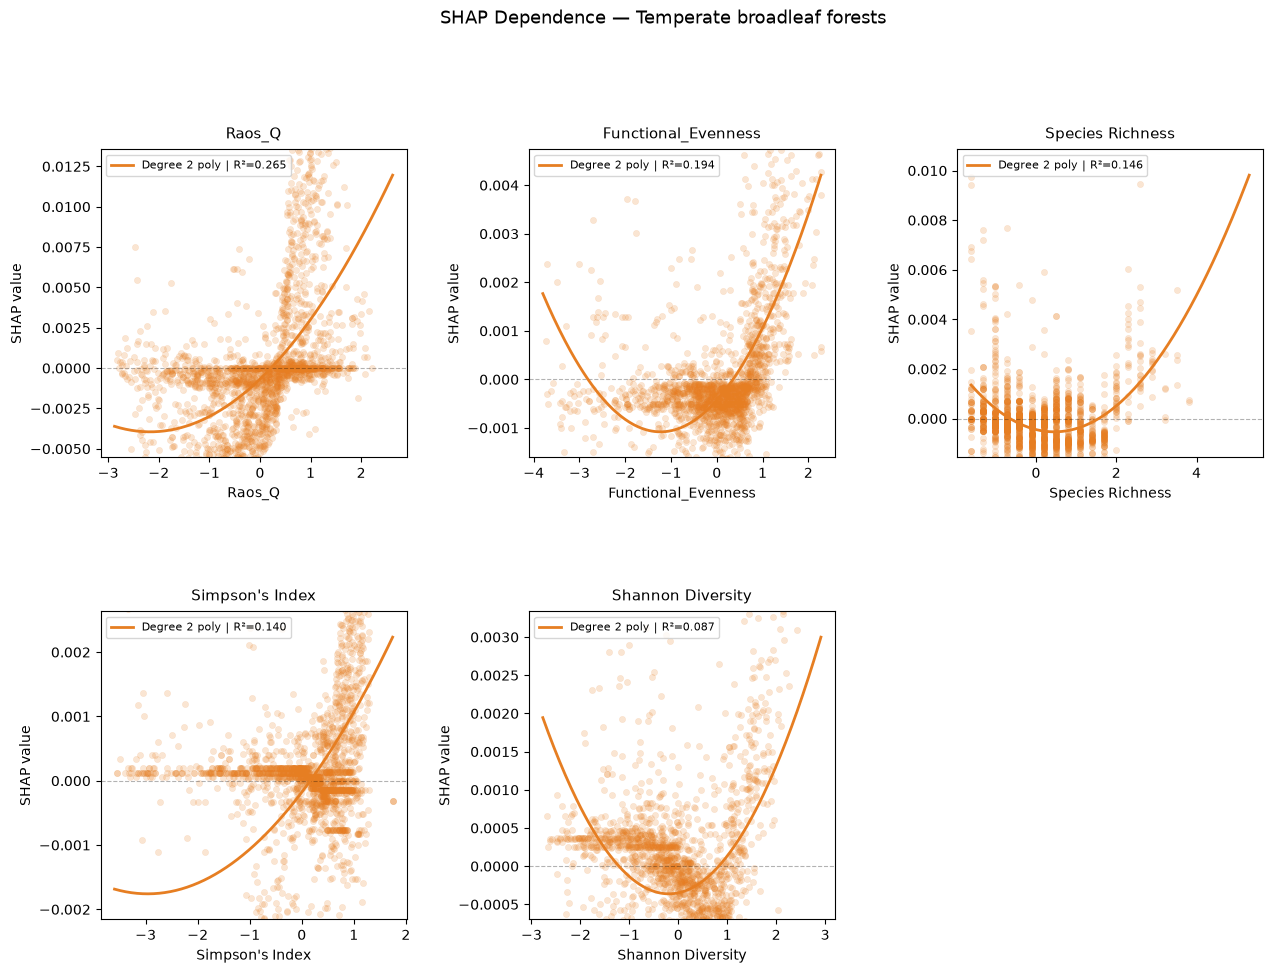

Training and evaluating for biome: Temperate conifer forests


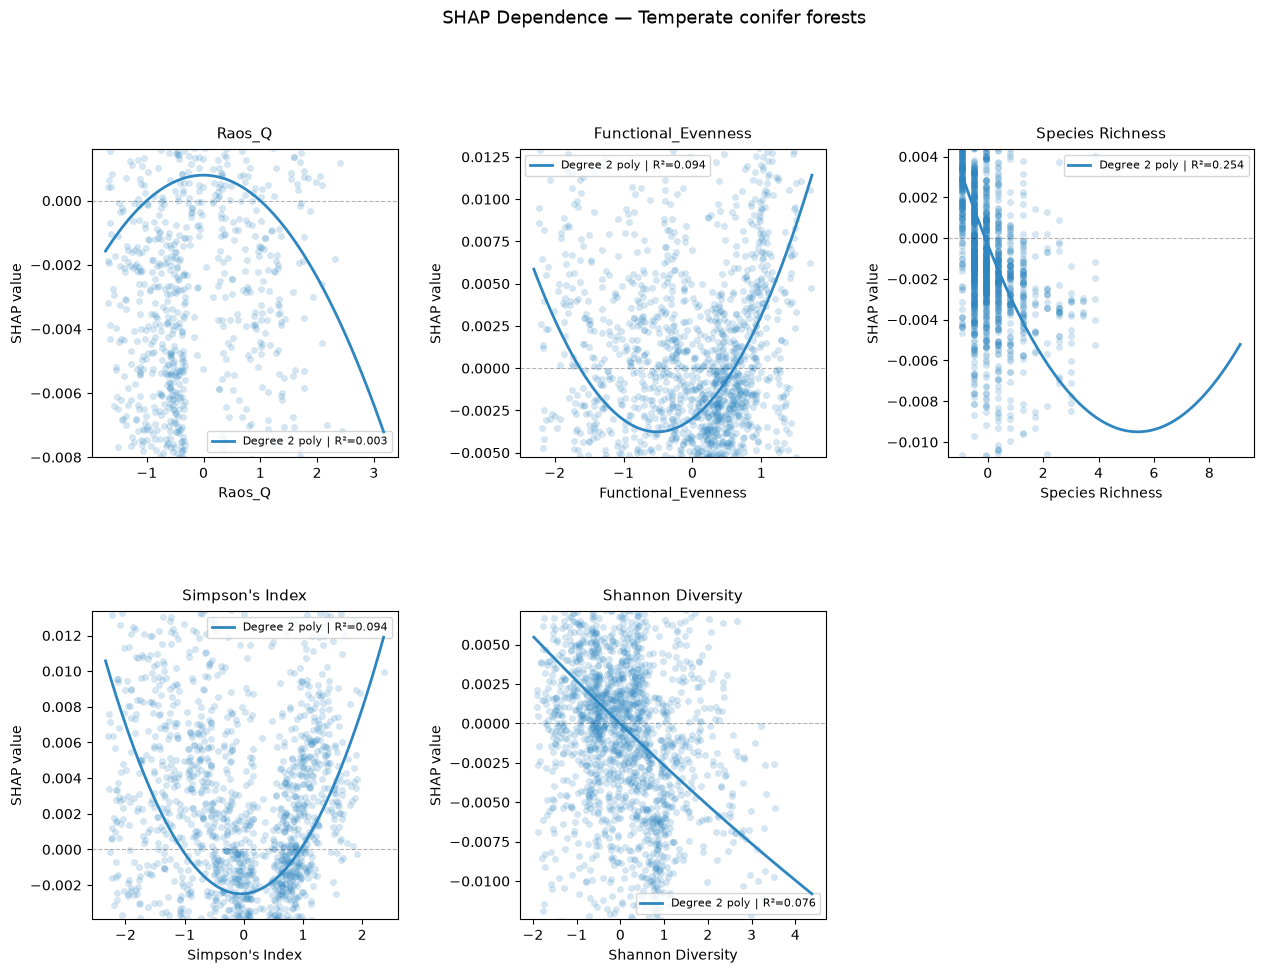

Training and evaluating for biome: Temperate grasslands


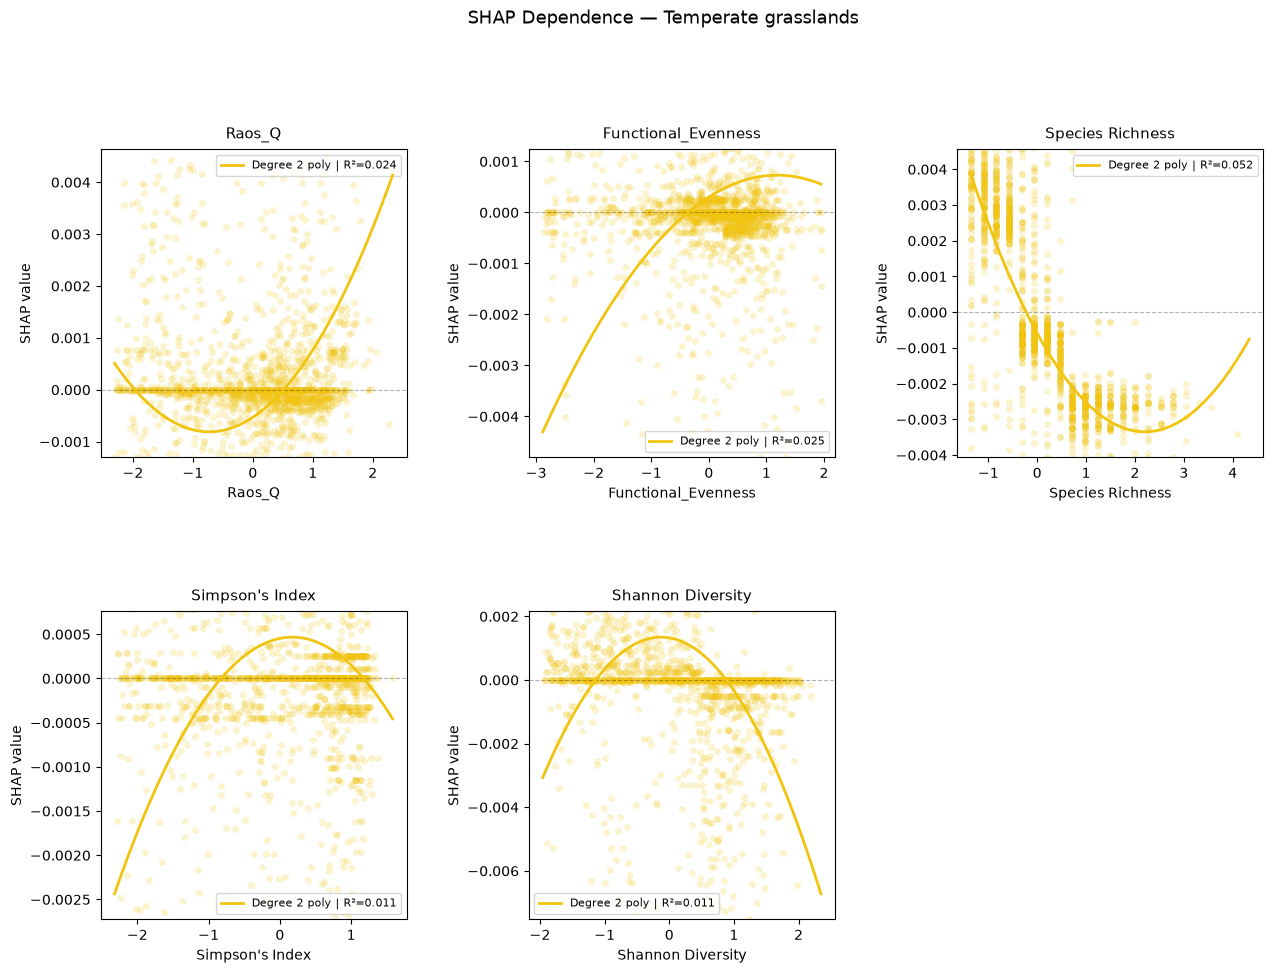

Training and evaluating for biome: Xeric shrublands


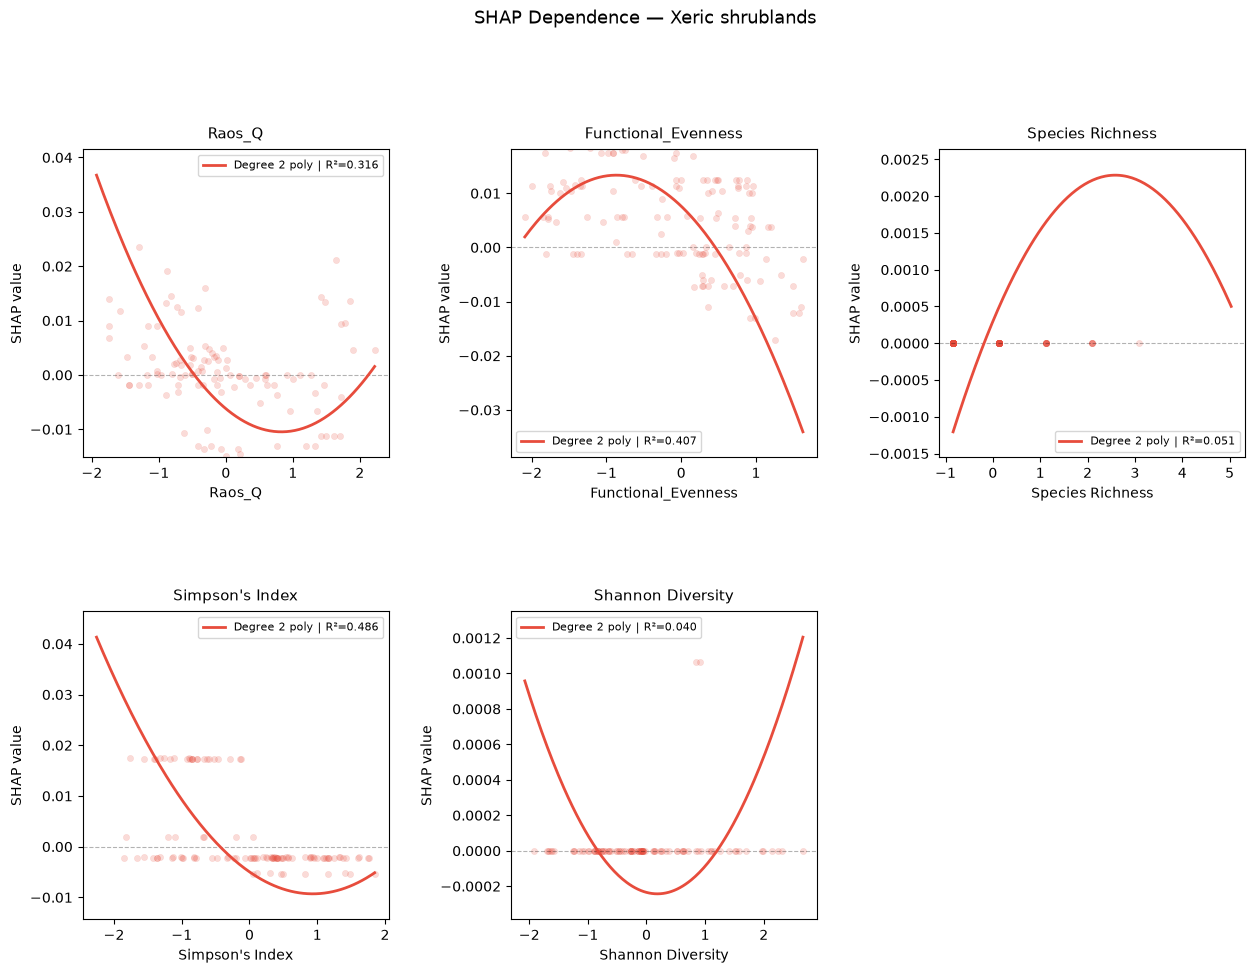

Training and evaluating for biome: Boreal and Tundra forests


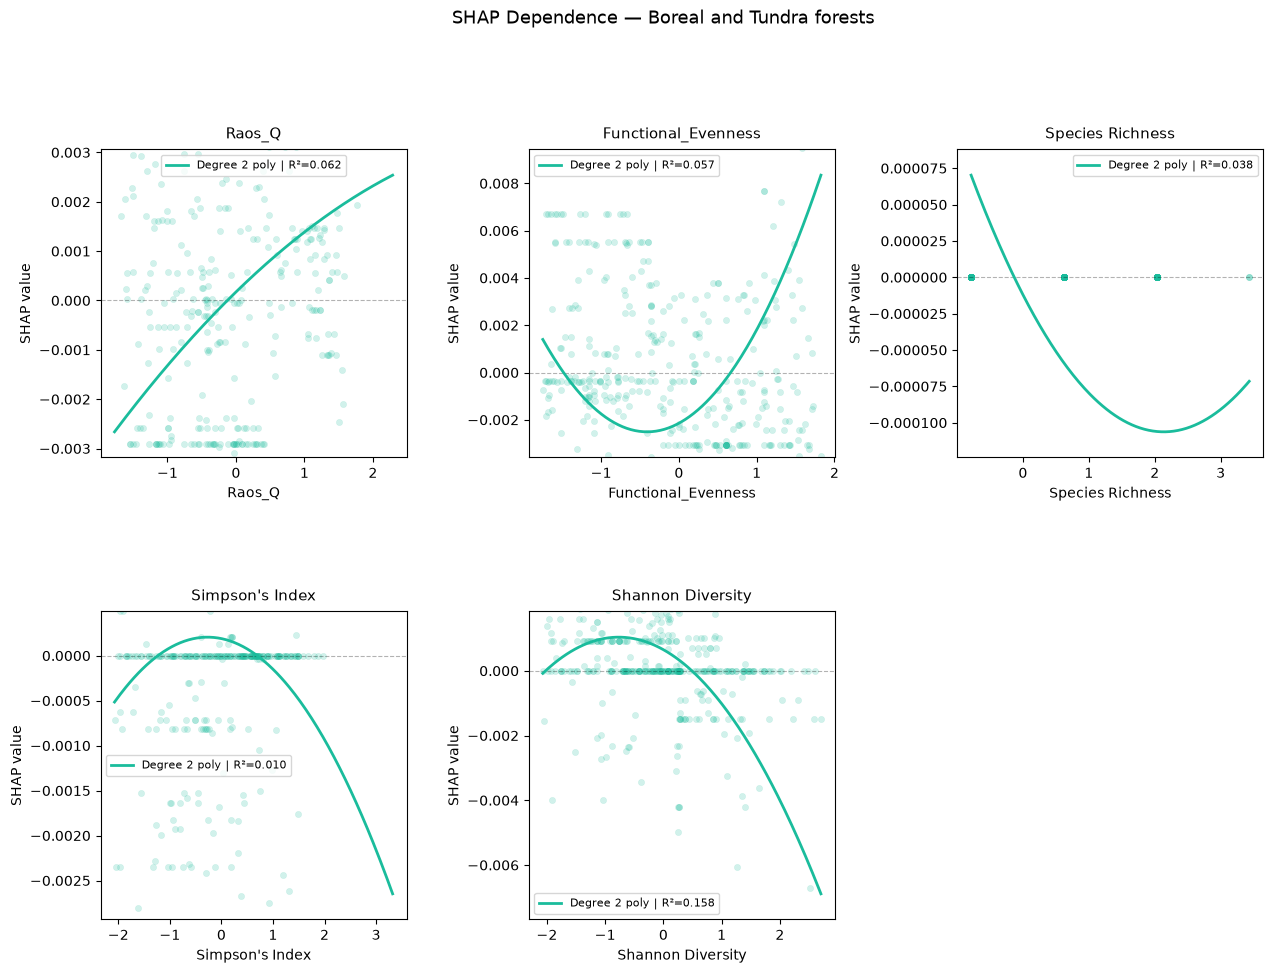

Training and evaluating for biome: Tropical


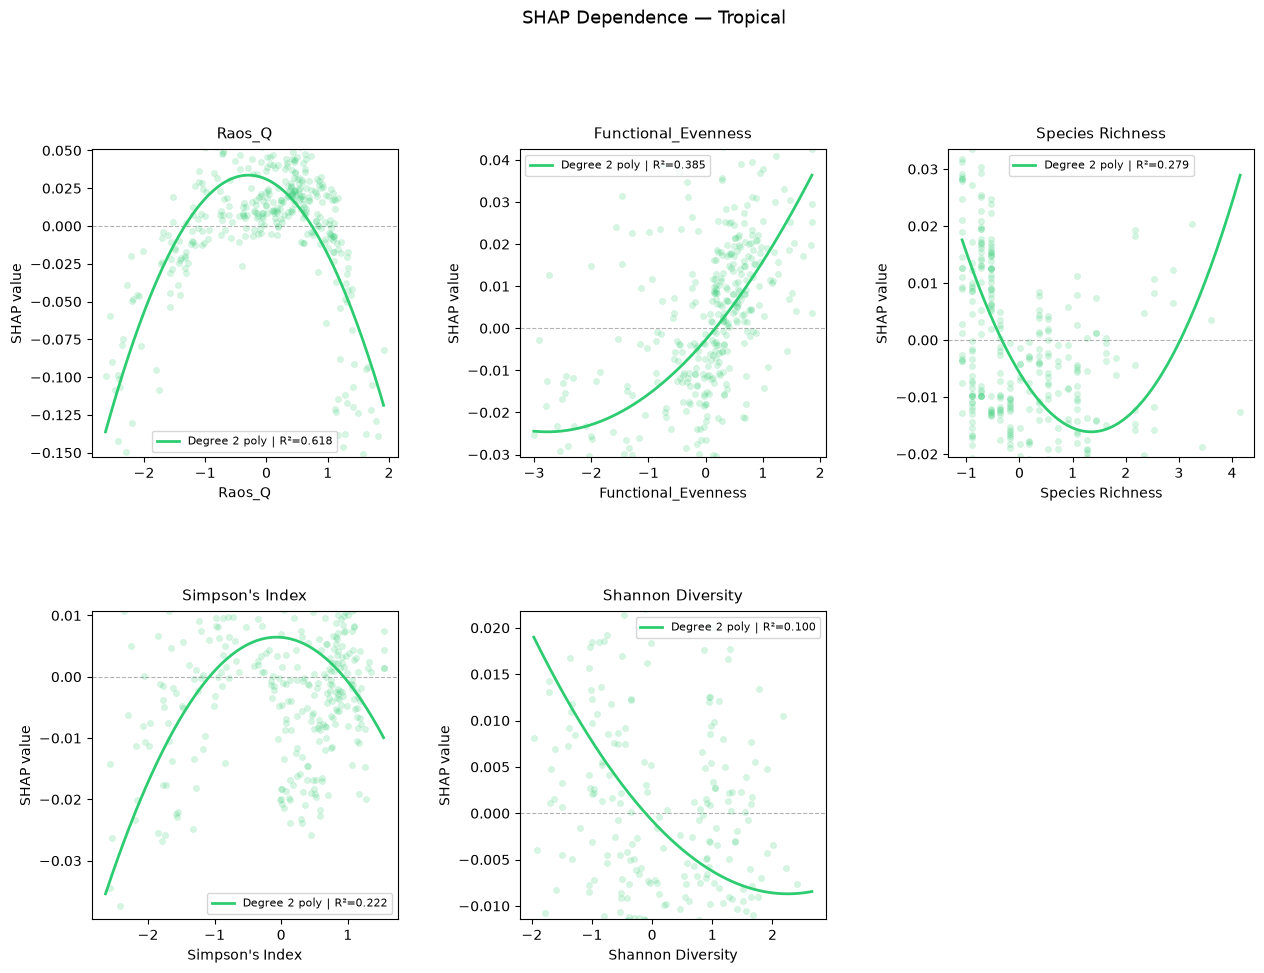

Training and evaluating for biome: Mediterranean woodlands


/tmp/ipykernel_604061/3558893872.py:68: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)
/tmp/ipykernel_604061/3558893872.py:94: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(y_min - padding, y_max + padding)


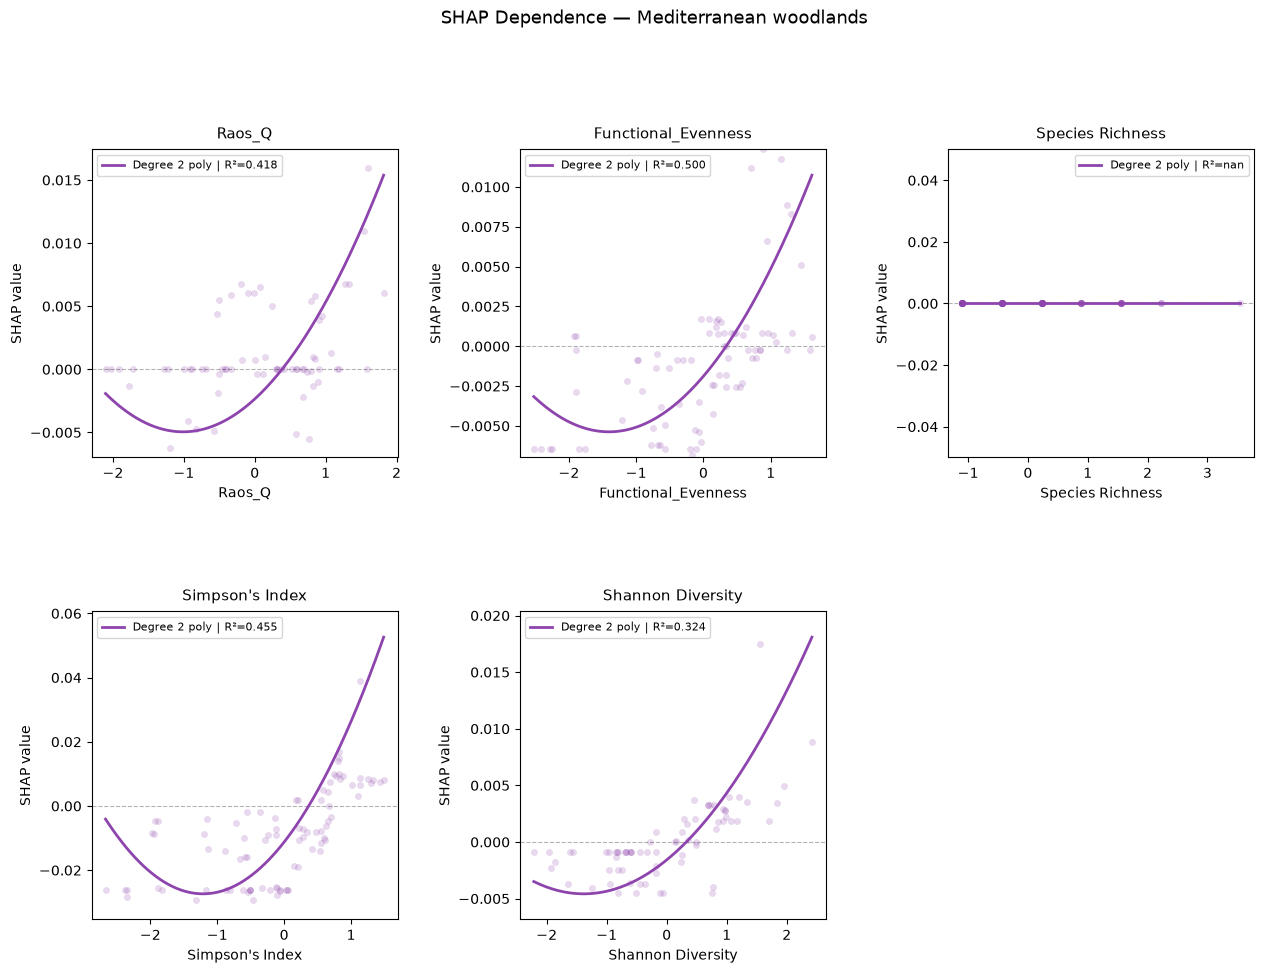

In [8]:
shap_df=pd.DataFrame(columns=['biome', 'feature', 'mean_abs_shap'])
shap_df2=pd.DataFrame()
slopes_df=pd.DataFrame(columns=['biome', 'feature', 'slope', 'zero_points'])

pdp_curves = {}  
for biome in biome_list:
    print(f"Training and evaluating for biome: {biome}")

    df= biome_dfs[biome]
    
    X=df.drop(columns=['transformed npp', 'PID', 'lat', 'lon', 'biome', 'treecover2000'])
    y=df['transformed npp'].values
    scaler= StandardScaler()
    X=scaler.fit_transform(X)
    
    X = pd.DataFrame(
        X,
        columns=scaler.feature_names_in_
    )
    model = xgb.XGBRegressor(**config[biome]['params'])

    model.fit(X, y )

    explainer = shap.Explainer(model, approximate=True)

    shap_vals = explainer.shap_values(X, approximate=True)
    mean_shap = shap_vals.mean(axis=0)
    model_features = getattr(model, "feature_names_in_", X.columns)
    shap_values = explainer(X, approximate=True )

    shap_importance = pd.DataFrame({
    "biome": biome,
    "feature": model_features,
    "mean_abs_shap": mean_shap
    }).sort_values("mean_abs_shap", ascending=False)

    all_shap_df = pd.DataFrame(
        shap_vals,
        columns=[f'shap_{col}' for col in X.columns],
        index=X.index
    )
    results = pd.concat(
        [
            df.loc[df.index, ["PID", "lat", "lon"]].reset_index(drop=True),
            all_shap_df.reset_index(drop=True)
        ],
        axis=1
    )
    shap_df2 = pd.concat([shap_df2,results], ignore_index=False)

    shap_df = pd.concat([shap_df, shap_importance], ignore_index=True)

    diversity_vars_f = ['Raos_Q', 'Functional_Evenness', 'Species Richness', "Simpson's Index", 'Shannon Diversity']
    diversity_vars_s =  ["Simpson's Index", 'Shannon Diversity', 'WSCI']

    # # Create the plot and get the Axes object
    # ax = shap.plots.bar(shap_values, show=False)

    # # Find all bar patches and change their color
    # for patch in ax.patches:
    #     patch.set_color("#3E47C6")  # SeaGreen
    #     # patch.set_color( "#125F10")
    # for text in ax.texts:
    #     text.set_color('black')
    # # Customize further, e.g., add a title
    # ax.set_title(f"SHAP Feature Importance - {biome}")

    # # Finally, display the plot
    # plt.show()
    # shap.plots.beeswarm(shap_values, color="orchid", max_display=None) #orchid vs darkolivegreen
    # shap.plots.beeswarm(shap_values.abs, color="darkolivegreen", max_display=None) #orchid vs darkolivegreen

    # plot_shap_with_polynomial_stats_v2(shap_vals, X, diversity_vars_f, diversity_vars_s, biome, degree=3, name=None)

    slopes, zero_points = plot_shap_with_polynomial_stats_v3(shap_vals, X, 
                                                             diversity_vars_f, biome, pdp_curves, degree=2, name=None, biome_color=biome_colors)

    slopes_df = pd.concat([slopes_df, pd.DataFrame({
        'biome': biome,
        'feature': diversity_vars_f,
        'slope': slopes,
        'zero_points': zero_points
    })], ignore_index=True)

In [9]:
pdp_curves_df = pd.DataFrame.from_dict(pdp_curves, orient='index')

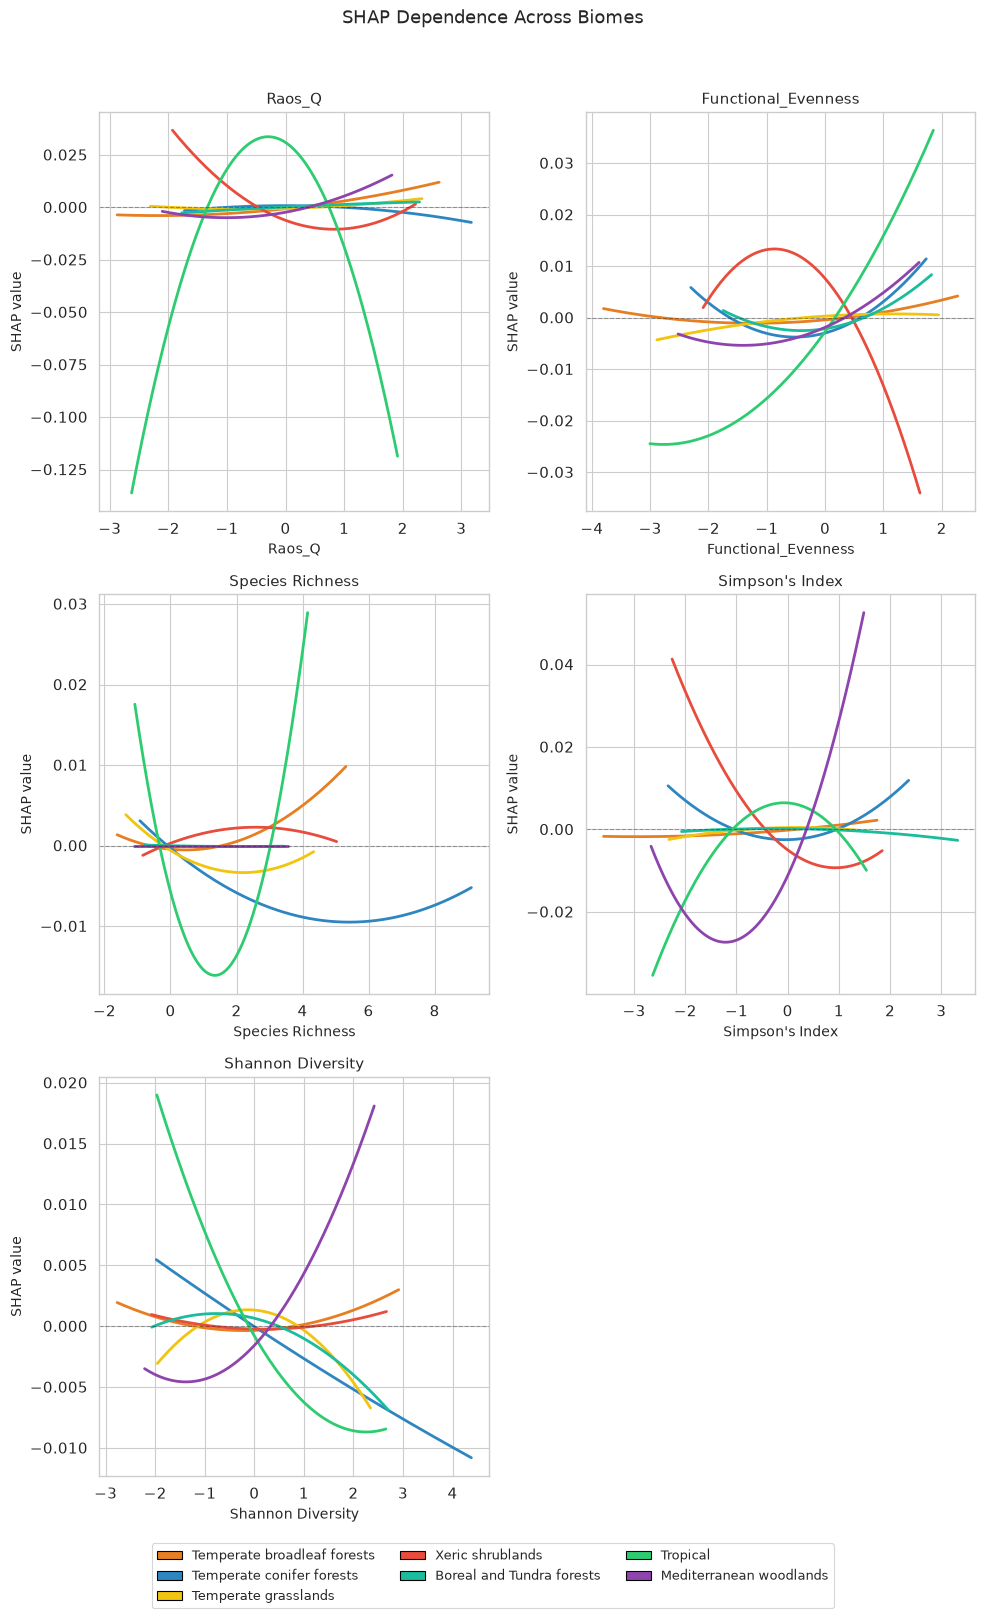

In [24]:

# --- After the loop ---
n_features = len(diversity_vars_f)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, 
                          figsize=(n_cols * 5, n_rows * 5))
axes_flat = np.array(axes).flatten()
fig.subplots_adjust(hspace=0.5, wspace=0.4)

for ax, var in zip(axes_flat, diversity_vars_f):
    for biome in biome_list:
        if var not in pdp_curves[biome]:
            continue
        x_smooth, y_smooth = pdp_curves[biome][var]
        ax.plot(x_smooth, y_smooth,
                c=biome_colors.get(biome, '#888888'),
                linewidth=2,
                label=biome)

    ax.axhline(0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=10)
    ax.set_title(var, fontsize=11)

# Hide unused axes
for ax in axes_flat[n_features:]:
    ax.set_visible(False)

# Shared legend
handles = [Patch(facecolor=biome_colors.get(b, '#888'), 
                 edgecolor='black', label=b)
           for b in biome_list]
fig.legend(handles=handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.05),
           ncol=3, fontsize=9, frameon=True)

fig.suptitle('SHAP Dependence Across Biomes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [25]:
slopes_df

,biome,feature,slope,zero_points
0,Temperate broadleaf forests,Raos_Q,0.003218,[11247]
1,Temperate broadleaf forests,Functional_Evenness,0.001192,"[3250, 13678]"
2,Temperate broadleaf forests,Species Richness,-0.000498,"[2800, 9169]"
3,Temperate broadleaf forests,Simpson's Index,0.001167,[14077]
4,Temperate broadleaf forests,Shannon Diversity,0.000187,"[5472, 12650]"
5,Temperate conifer forests,Raos_Q,0.000269,"[2958, 11130]"
6,Temperate conifer forests,Functional_Evenness,0.004128,"[3320, 14407]"
7,Temperate conifer forests,Species Richness,-0.003424,[1657]
8,Temperate conifer forests,Simpson's Index,0.000890,"[5496, 14017]"
9,Temperate conifer forests,Shannon Diversity,-0.002686,[6182]


In [12]:
import seaborn as sns

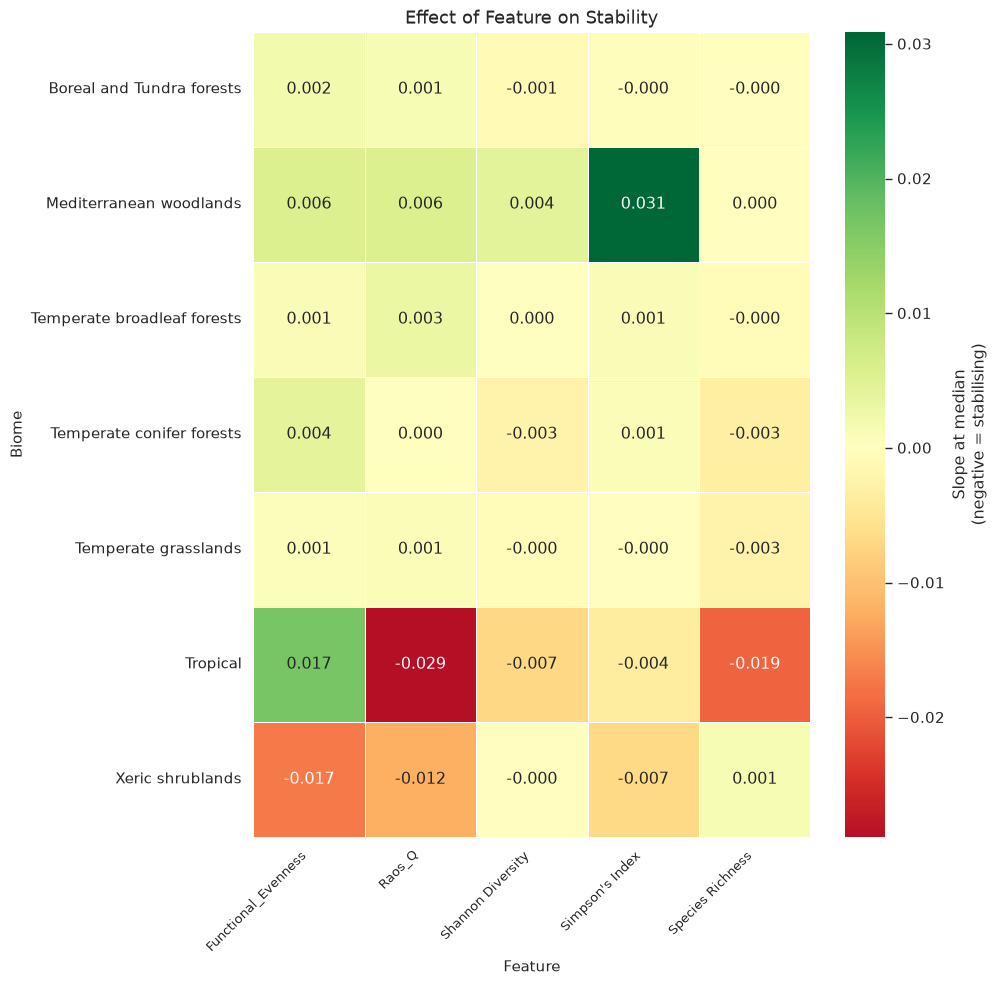

In [26]:
slopes_df['slope'] = pd.to_numeric(slopes_df['slope'], errors='coerce')

slope_pivot = slopes_df.pivot(index='biome', columns='feature', values='slope')

fig, ax = plt.subplots(figsize=(10,10))

sns.heatmap(
    slope_pivot,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Slope at median\n(negative = stabilising)'}
)

ax.set_title('Effect of Feature on Stability', fontsize=13)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Biome', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
slope_pivot

feature,Functional_Evenness,Raos_Q,Shannon Diversity,Simpson's Index,Species Richness
biome,,,,,
Boreal and Tundra forests,0.002000,0.001384,-0.001079,-0.000191,-0.000121
Mediterranean woodlands,0.005566,0.005530,0.004310,0.030893,0.000000
Temperate broadleaf forests,0.001192,0.003218,0.000187,0.001167,-0.000498
Temperate conifer forests,0.004128,0.000269,-0.002686,0.000890,-0.003424
Temperate grasslands,0.000581,0.000984,-0.000480,-0.000119,-0.002571
Tropical,0.016834,-0.028890,-0.007138,-0.003832,-0.019489
Xeric shrublands,-0.017042,-0.012106,-0.000137,-0.006856,0.001456


In [28]:
features=['Raos_Q', 'Functional_Evenness', 'Species Richness', 'Shannon Diversity', "Simpson's Index", 'WSCI']

shap_df1 = shap_df[shap_df["feature"].isin(features)]
shap_df1["mean_abs_shap"] = shap_df1["mean_abs_shap"] * 1e3
shap_df1 = shap_df1.pivot(
    index="feature",
    columns="biome",
    values="mean_abs_shap"
)

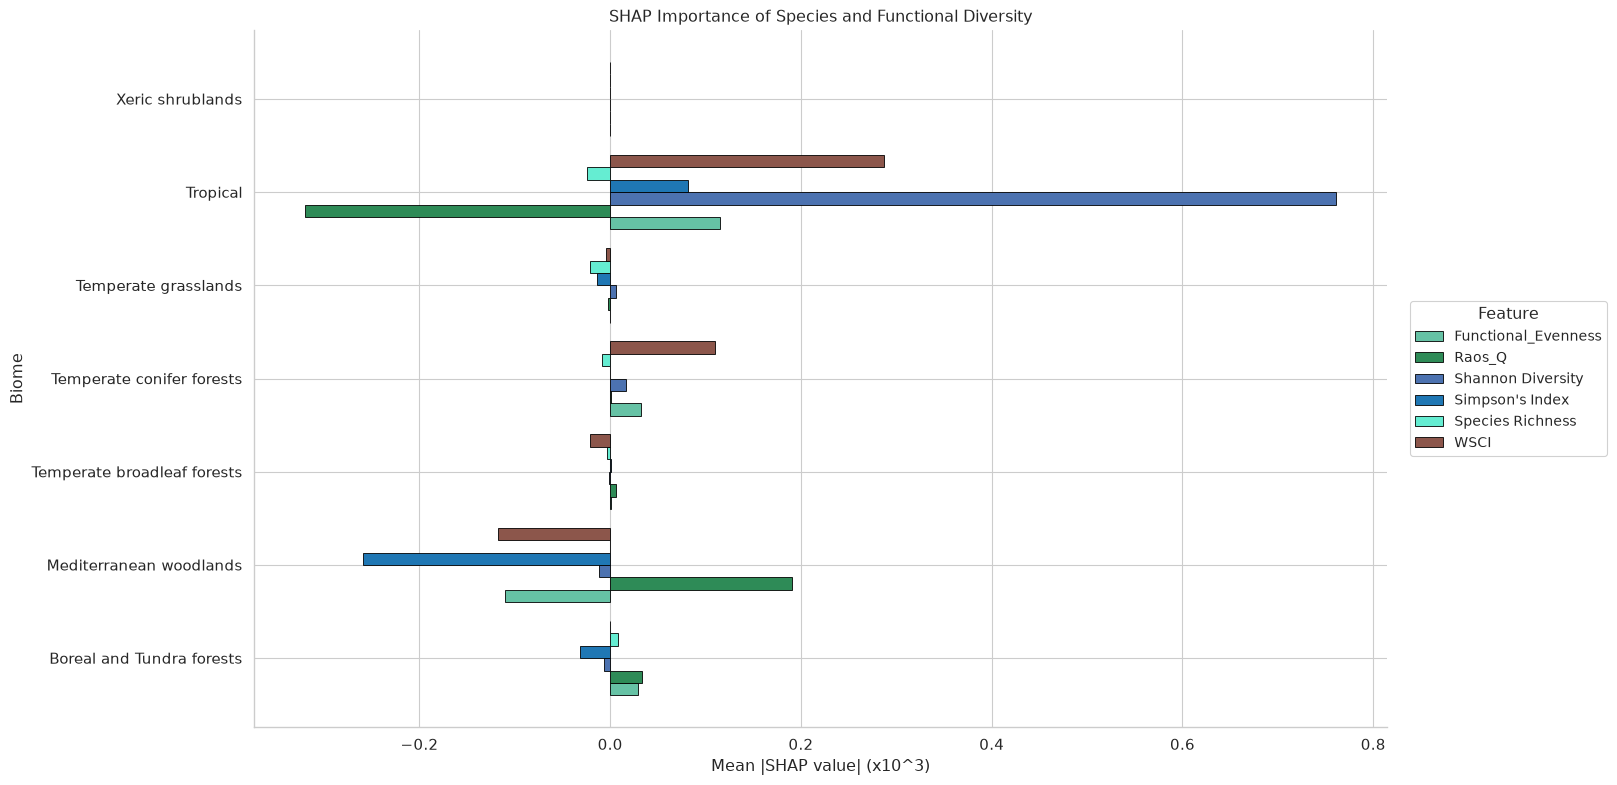

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
color_map = {
    # Functional Diversity (FD) - Shades of Green
    "Raos_Q": "#2E8B57",              # SeaGreen
    "Functional_Evenness": "#66C2A5",  # Medium Aquamarine/Lighter Green
    
    # Species Diversity (SD) - Shades of Blue
    "Simpson's Index": "#1F77B4",      # Medium Blue
    "Shannon Diversity": "#4C72B0",    # Steel Blue/Darker Blue
    "Species Richness": "#65EDD2",     # Light Blue
    
    # WSCI - Shades of Purple/Brown
    "WSCI": "#8C564B"                  # Brown/Purple
}
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

features = shap_df1.index
biomes = shap_df1.columns

y = np.arange(len(biomes))
height = 0.8 / len(features)

feature_colors = color_map

plt.figure(figsize=(20, 8))

for i, feature in enumerate(features):
    plt.barh(
        y + i * height,
        shap_df1.loc[feature].values,
        height,
        label=feature,
        color=color_map.get(feature, "grey"),                
        edgecolor="black",
        linewidth=0.6
    )

plt.yticks(y + height * (len(features) - 1) / 2, biomes)
plt.xlabel("Mean |SHAP value| (x10^3)")
plt.ylabel("Biome")
plt.title("SHAP Importance of Species and Functional Diversity")

plt.legend(
    title="Feature",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    framealpha=0.9,
    fontsize=10,
    borderaxespad=0
)

sns.despine()
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [17]:
eco=pd.read_csv('data/lookup/PID_with_ecoregion.csv')
biome_df=fd_df[['PID', 'biome', 'transformed npp', 'lon', 'lat', 'WSCI']]

In [18]:
subset_shap=shap_df2[[ 'PID','shap_Raos_Q', 'shap_Functional_Evenness',
                 'shap_Species Richness', 'shap_Shannon Diversity', 'shap_Simpson\'s Index', 'shap_Species Richness', 'shap_WSCI']]

In [19]:
eco_df=pd.merge(subset_shap, eco, on='PID', how='left')
eco=eco.merge(ecoregions, on='ECO_NAME', how='left')

biome_df=biome_df.merge(eco, on='PID', how='left')

shap_cols = [col for col in eco_df.columns if col.startswith("shap_")]
eco_shap_mean = eco_df.groupby("ECO_NAME")[shap_cols].mean()
eco_shap_mean["dominant_feature"] = eco_shap_mean.idxmax(axis=1)

eco_df=eco_shap_mean.merge(ecoregions, left_index=True, right_on="ECO_NAME", how="left")

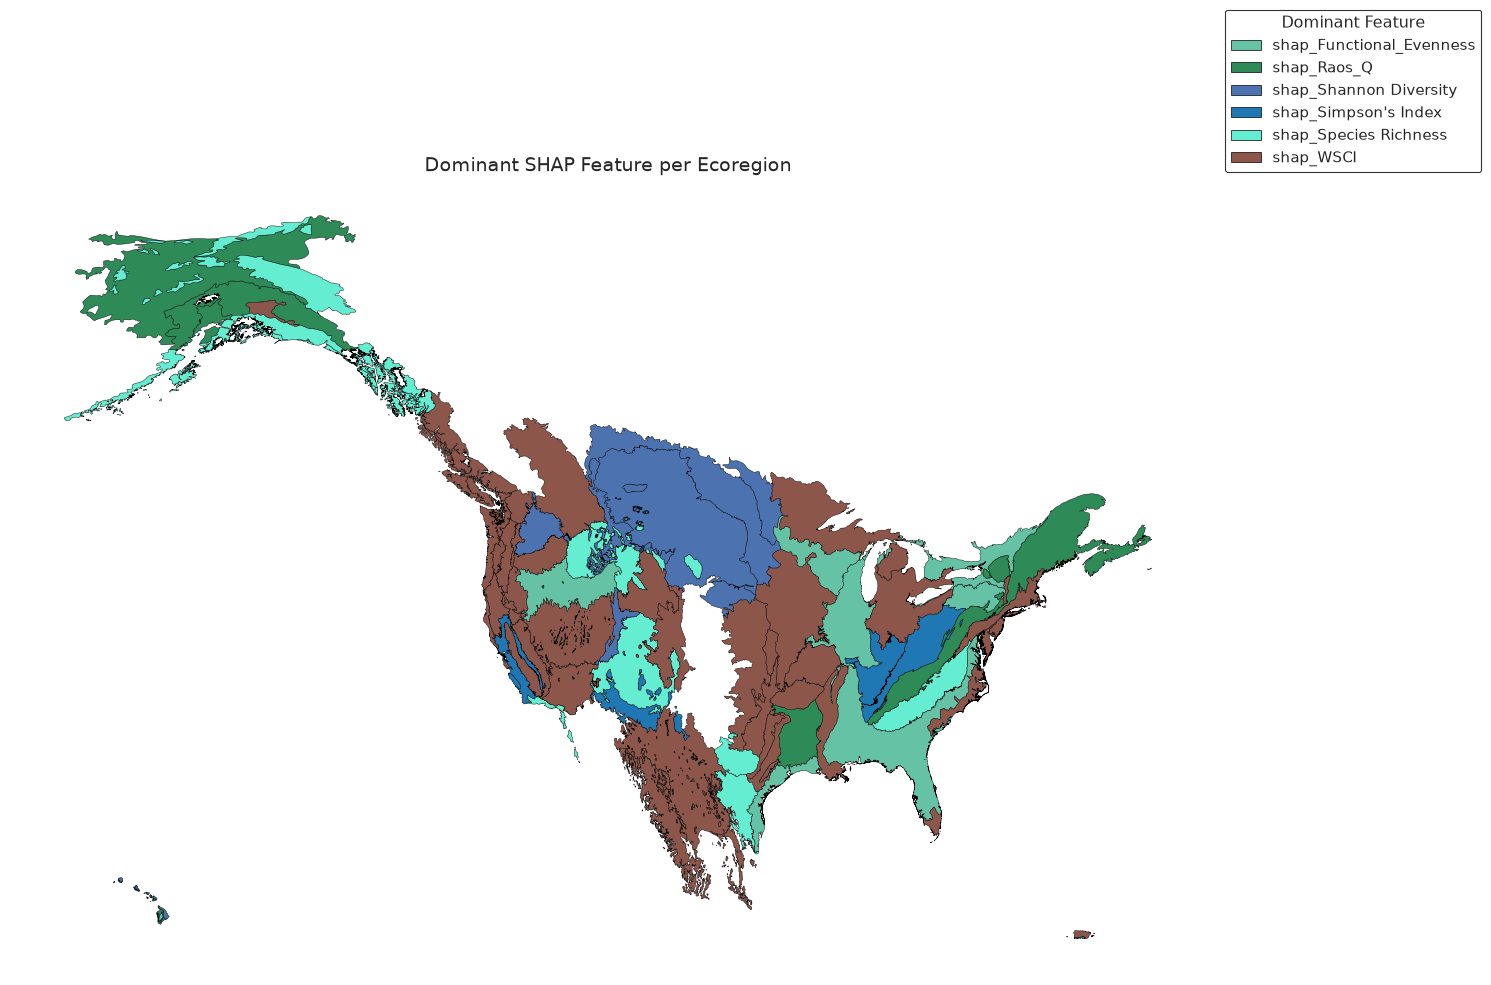

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd

eco_map = eco_df[['ECO_NAME', 'geometry', 'dominant_feature']].copy()
eco_map = gpd.GeoDataFrame(eco_map, geometry="geometry")
color_map = {
    # Functional Diversity (FD) - Shades of Green
    "shap_Raos_Q": "#2E8B57",              # SeaGreen
    "shap_Functional_Evenness": "#66C2A5",  # Medium Aquamarine/Lighter Green
    
    # Species Diversity (SD) - Shades of Blue
    "shap_Simpson's Index": "#1F77B4",      # Medium Blue
    "shap_Shannon Diversity": "#4C72B0",    # Steel Blue/Darker Blue
    "shap_Species Richness": "#65EDD2",     # Light Blue
    
    # WSCI - Shades of Purple/Brown
    "shap_WSCI": "#8C564B"                  # Brown/Purple
}
# Map colors directly to each row — no patch-matching needed
eco_map['color'] = eco_map['dominant_feature'].map(color_map)

# Reproject to a standard geographic CRS to fix scaling/connectivity artifacts
if eco_map.crs is None:
    eco_map = eco_map.set_crs("EPSG:4326")
else:
    eco_map = eco_map.to_crs("EPSG:4326")

# Optionally clip to valid lat/lon bounds to drop any corrupt geometries
from shapely.geometry import box
world_bounds = box(-180, -90, 180, 90)
eco_map['geometry'] = eco_map['geometry'].intersection(world_bounds)
eco_map = eco_map[~eco_map['geometry'].is_empty]

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

eco_map.plot(
    color=eco_map['color'],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

legend_elements = [
    Patch(facecolor=color_map[cat], edgecolor='black', label=cat, linewidth=0.5)
    for cat in sorted(color_map.keys())
]
ax.legend(
    handles=legend_elements,
    title="Dominant Feature",
    bbox_to_anchor=(1.01, 1),
    loc='lower left',
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

ax.set_title("Dominant SHAP Feature per Ecoregion", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [21]:
biome_df.drop(columns=['PID'], inplace=True)
biome_df.drop_duplicates(subset=['ECO_NAME'], inplace=True)

begin plot


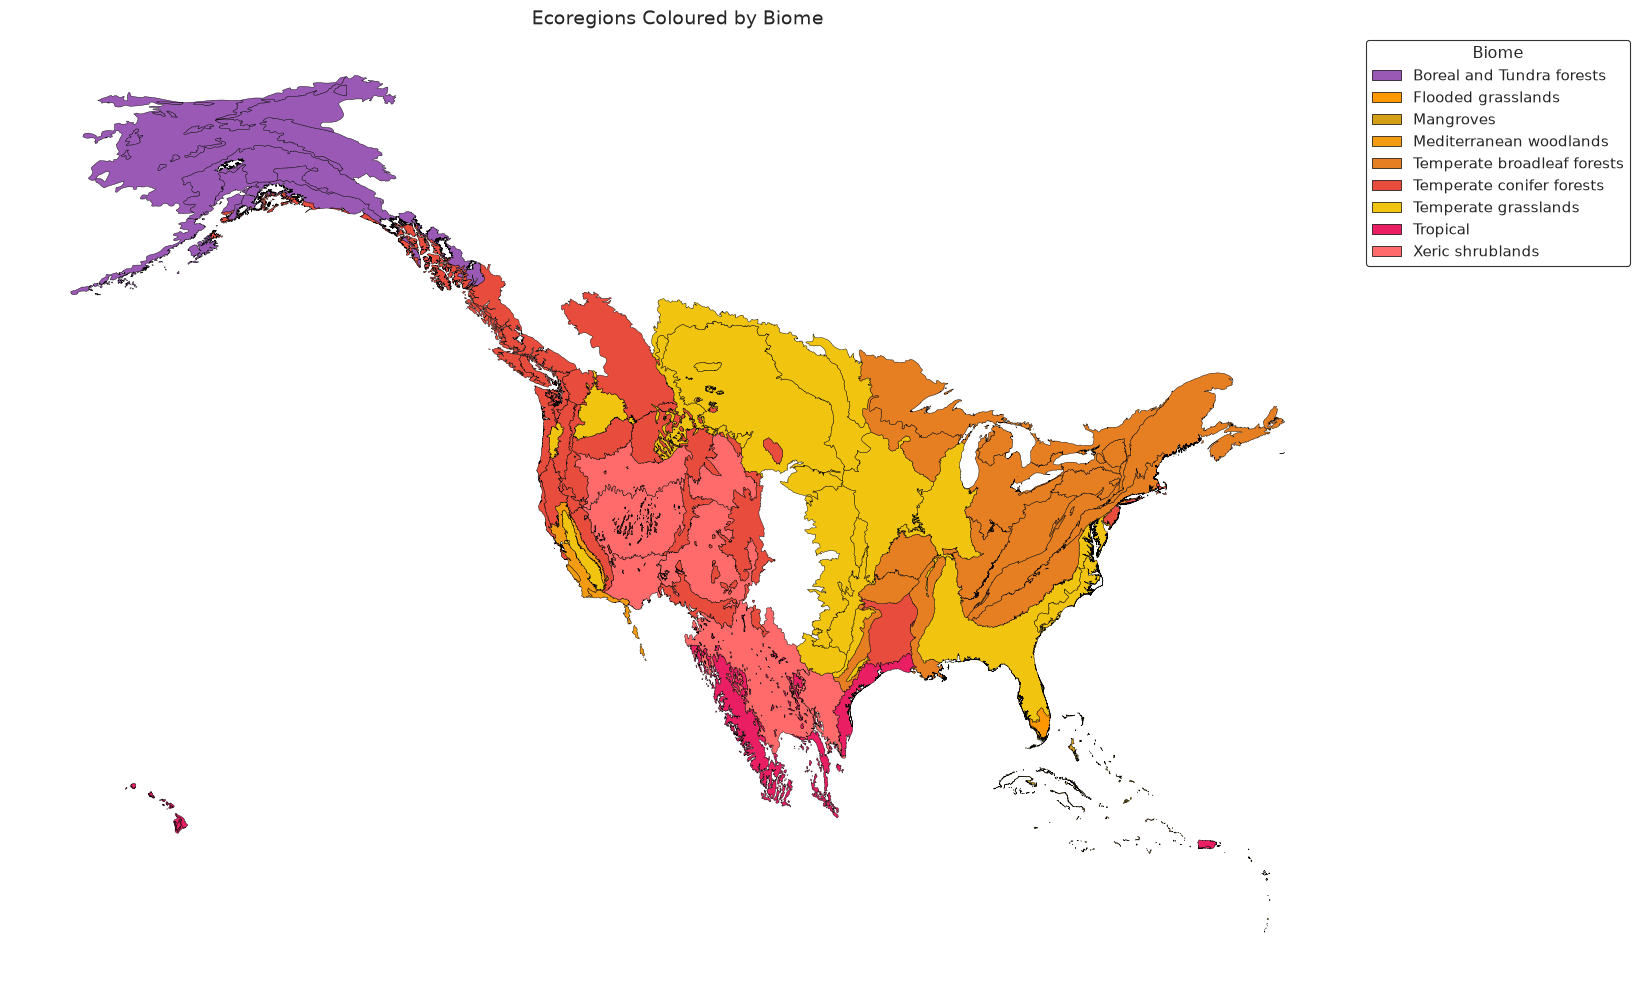

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd


biome_color = {
    'Temperate broadleaf forests': '#E67E22',      # Orange
    'Temperate conifer forests': '#E74C3C',        # Red
    'Temperate grasslands': '#F1C40F',             # Yellow
    'Xeric shrublands': '#FF6B6B',                 # Coral
    'Boreal and Tundra forests': '#9B59B6',        # Purple
    'Mediterranean woodlands': '#F39C12',          # Golden
    'Tropical': '#E91E63',                         # Pink
    'Flooded grasslands': '#FF9800',               # Dark Orange
    'Mangroves': '#D4A017',                        # Gold
    'NaN': '#95A5A6'                               # Gray
}

eco_map = biome_df[['geometry', 'biome']].copy()  # swap dominant_feature for biome
eco_map = gpd.GeoDataFrame(eco_map, geometry="geometry")

# Map biome colors
eco_map['color'] = eco_map['biome'].map(biome_color)

# Handle any biomes not in dict
eco_map['color'] = eco_map['color'].fillna('#D3D3D3')  # grey for unmatched

if eco_map.crs is None:
    eco_map = eco_map.set_crs("EPSG:4326")
else:
    eco_map = eco_map.to_crs("EPSG:4326")
    
print('begin plot')
fig, ax = plt.subplots(1, 1, figsize=(18, 10))
eco_map.plot(
    color=eco_map['color'],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

# Legend — only include biomes that actually appear in the data
present_biomes = eco_map['biome'].dropna().unique()
legend_elements = [
    Patch(facecolor=biome_color.get(b, '#D3D3D3'), edgecolor='black', 
          label=b, linewidth=0.5)
    for b in sorted(present_biomes)
]

ax.legend(
    handles=legend_elements,
    title="Biome",
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

ax.set_title("Ecoregions Coloured by Biome", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

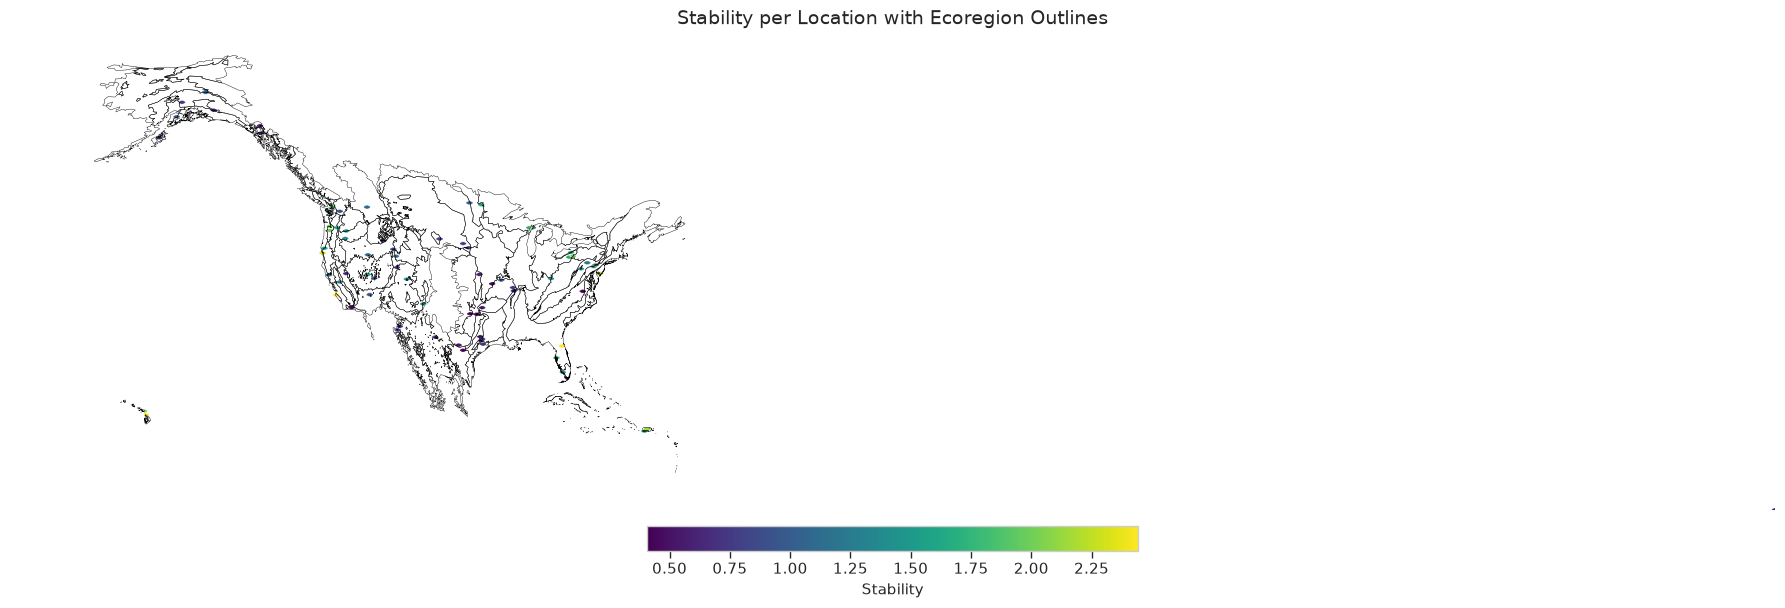

In [32]:
import matplotlib.pyplot as plt
import geopandas as gpd
import datashader as ds
import datashader.transfer_functions as tf
import numpy as np

# --- 1. Simplify outlines ---
eco_map = biome_df[['ECO_NAME','geometry']].copy()
eco_map.drop_duplicates(subset=['ECO_NAME'], inplace=True)
eco_map = gpd.GeoDataFrame(eco_map, geometry="geometry")
if eco_map.crs is None:
    eco_map = eco_map.set_crs("EPSG:4326")
else:
    eco_map = eco_map.to_crs("EPSG:4326")

eco_map['geometry'] = eco_map['geometry'].simplify(0.1, preserve_topology=True)

# --- 2. Datashader raster of points ---
canvas = ds.Canvas(plot_width=1800, plot_height=900,
                   x_range=(biome_df['lon'].min(), biome_df['lon'].max()),
                   y_range=(biome_df['lat'].min(), biome_df['lat'].max()))

agg = canvas.points(biome_df, 'lon', 'lat', ds.mean('transformed npp'))
agg_spread = tf.spread(agg, px=3)  # increase px for thicker points
# Convert to numpy for matplotlib
agg_np = agg_spread.values  # shape (900, 1800)

# --- 3. Plot ---
fig, ax = plt.subplots(1, 1, figsize=(18, 9))

# Extent for imshow
lon_min, lon_max = biome_df['lon'].min(), biome_df['lon'].max()
lat_min, lat_max = biome_df['lat'].min(), biome_df['lat'].max()
extent = [lon_min, lon_max, lat_min, lat_max]

# Plot datashader raster
vmin = np.nanpercentile(agg_np, 5)
vmax = np.nanpercentile(agg_np, 95)

im = ax.imshow(
    agg_np,
    origin='lower',
    extent=extent,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
    aspect='auto',
    zorder=1
)

# Polygon outlines on top
eco_map.plot(
    facecolor='none',
    edgecolor='black',
    linewidth=0.3,
    ax=ax,
    zorder=2
)

# Colorbar
cbar = plt.colorbar(im, ax=ax,
                     orientation='horizontal',
                     shrink=0.4,
                     pad=0.02,
                     fraction=0.03)
cbar.set_label('Stability', fontsize=11)

ax.set_title("Stability per Location with Ecoregion Outlines", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()